### Summary
Web : server-client -> url
request, response -> get, post

#### 페이지 종류
동적페이지 : URL 변환 없이 페이지 데이터 변경 -> json
정적페이지 : URL 변환 해서 페이지 데이터 변겅 -> HTML

#### 동적 데이터 수집 절차
1. 웹서비스 분석(개발자도구) : URL
2. request(url, params, headers) -> response(json) -> json(str)
3. json(str) -> list, dict -> dataframe

#### API를 이용한 데이터 수집 절차
1. APP 등록 -> application key
2. api 문서 확인
3. request(url, params, headers(application key)) -> response(json) -> json(str)
4. json(str) -> list, dict -> dataframe

#### 크롤링 정책
robots.txt 파일에 크롤링 정책 설명  
ex) tes.com/robots.txt  
크롤링에 대한 법적 제제X  
과도한 크롤링으로 서비스에 영향을 주었을때 문제가 될 수 있음 -> 영업방해  
크롤링을 할때는 되도록 API를 사용  

### 네이버 검색어 트렌드 수집
1. application key   
2. document -> url, parmas, headers  
3. request(url, params, headers) -> response(json) -> json(str)  
4. json(str) -> prepocessint -> dataframe  
5. 시각화

In [3]:
import pandas as pd
import requests, json

#### 1. application key 

In [4]:
# 1. application key 
CLIENT_ID, CLIENT_SECRET = "za1kdvINTuafBgNr_uM_", "yJfgi3NSn6"

#### 2. document -> url, parmas, headers

In [5]:
# 2. document -> url, parmas, headers
url="https://openapi.naver.com/v1/datalab/search"
params={
    "startDate":"2018-01-01",
    "endDate":"2022-07-31",
    "timeUnit":"month",
    "keywordGroups": [
        {"groupName":"트위터","keywords":["트위터","트윗"]},
        {"groupName":"페이스북","keywords":["페이스북","페북"]},
        {"groupName":"인스타그램","keywords":["인스타그램","인스타"]},
    ]
}
headers={
    "Content-Type": "application/json",
    "X-Naver-Client-Id": CLIENT_ID,
    "X-Naver-Client-Secret": CLIENT_SECRET,
}

#### 3. request(url, params, headers) -> response(json) -> json(str)

In [7]:
# 3. request(url, params, headers) -> response(json) -> json(str)
# dumps -> 한글때매 사용
response=requests.post(url,json.dumps(params),headers=headers)

In [9]:
response.text[:300]

'{"startDate":"2018-01-01","endDate":"2022-07-31","timeUnit":"month","results":[{"title":"트위터","keywords":["트위터","트윗"],"data":[{"period":"2018-01-01","ratio":14.59502},{"period":"2018-02-01","ratio":13.0238},{"period":"2018-03-01","ratio":12.97953},{"period":"2018-04-01","ratio":12.82991},{"period":"'

#### 4. json(str) -> prepocessing -> dataframe
list comprehension : 간단한 for, if 문을 사용하여 리스트 데이터를 만들때 사용하는 방법  
Quiz. 0~9까지 홀수만 제곱해서 list 출력

In [17]:
result=[]
for num in range(10):
    if num %2:
        result.append(num**2)
result

[1, 9, 25, 49, 81]

In [18]:
#list comprehension
#for -> if -> num**2
result=[num**2 for num in range(10) if num %2 ]
result

[1, 9, 25, 49, 81]

In [22]:
data[0]["data"][:2]

[{'period': '2018-01-01', 'ratio': 14.59502},
 {'period': '2018-02-01', 'ratio': 13.0238}]

In [24]:
# 4. json(str) -> prepocessint -> dataframe
data=response.json()['results']
# list comprehension
df=pd.DataFrame({
    "date":[period["period"] for period in data[0]["data"]],
    "twitter":[ratio["ratio"] for ratio in data[0]["data"]],
    "facebook":[ratio["ratio"] for ratio in data[1]["data"]],
    "instagram":[ratio["ratio"] for ratio in data[2]["data"]]
})
df.tail(2)

,date,twitter,facebook,instagram
53,2022-06-01,23.24110,20.04381,21.63141
54,2022-07-01,24.06197,19.53712,21.40551


#### 5.시각화

<AxesSubplot:>

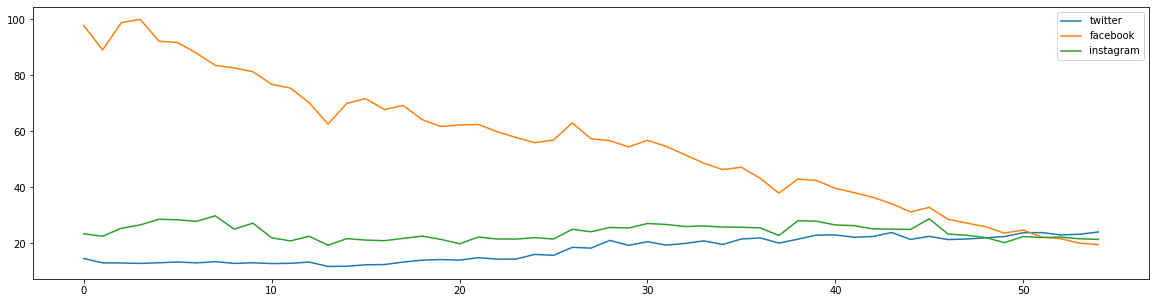

In [25]:
# 5.시각화
df.plot(figsize=(20,5))

In [ ]:
# pandas 공부하기 -> 실제 패키지 사이트가서 확인
# https://pandas.pydata.org/docs/user_guide/10min.html

### 과제 : 카카오 api 사용해서 주소 -> 위도, 경도, 우편번호 또는 반대 API 사용
REST api키 사용, https://developers.kakao.com/docs/latest/ko/local/dev-guide
https://bit.ly/3vv1IPl